***BUSINESS UNDERSTANDING***

Predicting the age of abalone from physical measurements.  The age of abalone is determined by cutting the shell through the cone, staining it, and counting the number of rings through a microscope -- a boring and time-consuming task.  Other measurements, which are easier to obtain, are used to predict the age.  Further information, such as weather patterns and location (hence food availability) may be required to solve the problem.

From the original data examples with missing values were removed (the majority having the predicted value missing), and the ranges of the continuous values have been scaled for use with an ANN (by dividing by 200).

Has Missing Values? No

Given is the attribute name, attribute type, the measurement unit and a brief description.  The number of rings is the value to predict: either as a continuous value or as a classification problem.

Name / Data Type / Measurement Unit / Description
---
Sex / nominal / -- / M, F, and I (infant)
Length / continuous / mm / Longest shell measurement
Diameter	/ continuous / mm / perpendicular to length
Height / continuous / mm / with meat in shell
Whole weight / continuous / grams / whole abalone
Shucked weight / continuous	 / grams / weight of meat
Viscera weight / continuous / grams / gut weight (after bleeding)
Shell weight / continuous / grams / after being dried
Rings / integer / -- / +1.5 gives the age in years

The readme file contains attribute statistics.

***LOADING LIBRARIES***

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.preprocessing import OneHotEncoder


***LOADING DATA***

In [2]:
df = pd.read_csv('Data\Abalone_Converted.csv')

Current Features

In [3]:
df = df.rename(columns={'Column1': 'Sex','Column2': 'Length','Column3': 'Diameter','Column4': 'Height','Column5': 'Whole weight','Column6': 'Shucked weight','Column7': 'Viscera weight','Column8': 'Shell weight','Column9': 'Rings'})

***DATA UNDERSTANDING***

In [4]:
rows, columns = df.shape
print(f"The Abalonedataset has {rows} rows and {columns} columns.")

The Abalonedataset has 4177 rows and 9 columns.


In [5]:
df.head()

,Sex,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


In [6]:
df.describe(include='object')

C:\Users\Mwangi Maina\AppData\Local\Temp\ipykernel_22748\87514550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,Sex
count,4177
unique,3
top,M
freq,1528


In [7]:
df['Sex'].describe()

count     4177
unique       3
top          M
freq      1528
Name: Sex, dtype: object

In [8]:
df.describe()

,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
count,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000
mean,0.523992,0.407881,0.139516,0.828742,0.359367,0.180594,0.238831,9.933684
std,0.120093,0.099240,0.041827,0.490389,0.221963,0.109614,0.139203,3.224169
min,0.075000,0.055000,0.000000,0.002000,0.001000,0.000500,0.001500,1.000000
25%,0.450000,0.350000,0.115000,0.441500,0.186000,0.093500,0.130000,8.000000
50%,0.545000,0.425000,0.140000,0.799500,0.336000,0.171000,0.234000,9.000000
75%,0.615000,0.480000,0.165000,1.153000,0.502000,0.253000,0.329000,11.000000
max,0.815000,0.650000,1.130000,2.825500,1.488000,0.760000,1.005000,29.000000


***DATA PREPARATION***

In [9]:
df_2 = df[['Rings', 'Length']]

In [10]:
df_2.head()

,Rings,Length
0,15,0.455
1,7,0.350
2,9,0.530
3,10,0.440
4,7,0.330


In [11]:
df.info

<bound method DataFrame.info of      Sex  Length  Diameter  Height  Whole weight  Shucked weight  \
0      M   0.455     0.365   0.095        0.5140          0.2245   
1      M   0.350     0.265   0.090        0.2255          0.0995   
2      F   0.530     0.420   0.135        0.6770          0.2565   
3      M   0.440     0.365   0.125        0.5160          0.2155   
4      I   0.330     0.255   0.080        0.2050          0.0895   
...   ..     ...       ...     ...           ...             ...   
4172   F   0.565     0.450   0.165        0.8870          0.3700   
4173   M   0.590     0.440   0.135        0.9660          0.4390   
4174   M   0.600     0.475   0.205        1.1760          0.5255   
4175   F   0.625     0.485   0.150        1.0945          0.5310   
4176   M   0.710     0.555   0.195        1.9485          0.9455   

      Viscera weight  Shell weight  Rings  
0             0.1010        0.1500     15  
1             0.0485        0.0700      7  
2             0.141

In [12]:
rows, columns = df.shape
output = f'The Abalone dataset has {rows} records and {columns} features.'
output

'The Abalone dataset has 4177 records and 9 features.'

***Univariate Analysis***

In [13]:
#list(df.columns)
df.columns

Index(['Sex', 'Length', 'Diameter', 'Height', 'Whole weight', 'Shucked weight',
       'Viscera weight', 'Shell weight', 'Rings'],
      dtype='str')

***Bivariate Analysis***

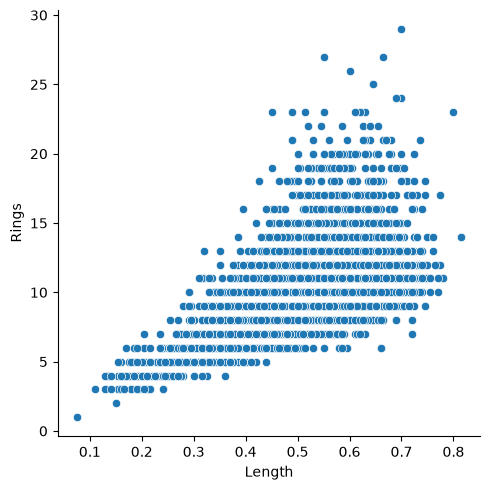

In [14]:
sns.relplot(data=df, x='Length', y='Rings')

***MODELING***

In [15]:
x = pd.DataFrame(df_2['Length'])
y = pd.DataFrame(df_2['Rings'])

In [16]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=30, random_state=42)

In [17]:
linear_reg_model = LinearRegression()

In [18]:
linear_reg_model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 1)",[[14.92]]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Length']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[2.11]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


In [19]:
y_predicted = linear_reg_model.predict(x_test)

In [20]:
y_predicted

array([[11.1360387 ],
       [10.91225309],
       [10.46468185],
       [11.58360994],
       [ 9.19656335],
       [ 9.8679202 ],
       [ 9.8679202 ],
       [ 9.27115855],
       [ 7.55546882],
       [10.83765788],
       [10.83765788],
       [ 7.48087361],
       [ 9.27115855],
       [ 7.55546882],
       [ 9.49494417],
       [10.53927706],
       [10.76306267],
       [10.31549144],
       [12.55334762],
       [ 9.56953938],
       [12.92632365],
       [12.62794282],
       [11.35982432],
       [11.43441953],
       [10.98684829],
       [ 8.5998017 ],
       [ 9.8679202 ],
       [ 9.793325  ],
       [10.68846747],
       [ 9.71872979]])

In [21]:
user_height_input = float(input('Enter the Length of the abalone in mm (Enter numbers only): '))
y_hat = np.floor(linear_reg_model.predict([[user_height_input]])[0])
y_hat

c:\Users\Mwangi Maina\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([14.])

***EVALUATION***

In [22]:
x_test

,Length
866,0.605
1483,0.590
599,0.560
1702,0.635
670,0.475
2430,0.520
1590,0.520
949,0.480
4026,0.365
3668,0.585


In [23]:
y_test

,Rings
866,9
1483,8
599,16
1702,9
670,14
2430,11
1590,7
949,6
4026,7
3668,10


In [24]:
r2_score(y_test, y_predicted)

0.14574916040251107

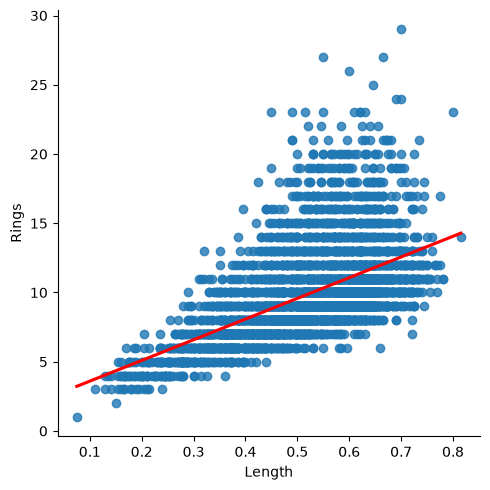

In [25]:
sns.lmplot(data=df, x='Length', y='Rings', ci=None, line_kws={'color':'red'})

***Encoding (Binary & One hot encoding)***

Binary Encoding

In [26]:
df.columns

Index(['Sex', 'Length', 'Diameter', 'Height', 'Whole weight', 'Shucked weight',
       'Viscera weight', 'Shell weight', 'Rings'],
      dtype='str')

In [27]:
df.head(5)

,Sex,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


In [28]:
binary_columns = ['']

In [29]:
#for col in binary_columns:
#    df[col] = df[col].map({'yes': 1, 'no': 0})

In [30]:
one_hot = pd.get_dummies(df['Sex'], dtype=int)
one_hot.head(5)

,F,I,M
0,0,0,1
1,0,0,1
2,1,0,0
3,0,0,1
4,0,1,0


In [31]:
encoder = OneHotEncoder(handle_unknown='ignore')
encoder.fit(df[['Sex']])
encoder.categories_
encoded_sex = encoder.transform(df[['Sex']]).toarray()

encoded_df = pd.DataFrame(
    encoded_sex,
    columns=encoder.get_feature_names_out(['Sex'])
    )

In [32]:
encoded_df.head(5)

,Sex_F,Sex_I,Sex_M
0,0.0,0.0,1.0
1,0.0,0.0,1.0
2,1.0,0.0,0.0
3,0.0,0.0,1.0
4,0.0,1.0,0.0


In [33]:
df.head(5)

,Sex,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


**concatenation of both dataframes (original and encoded df)**


In [34]:
# reset the index or first df
df_2 = df.reset_index(drop=True)

# reset index of the encoded df
encoded_df = encoded_df.reset_index(drop=True)

# combine the two df's
df_3 = pd.concat([df_2.drop(columns=['Sex']), encoded_df], axis=1)

In [35]:
df_3.head(5)

,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings,Sex_F,Sex_I,Sex_M
0,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15,0.0,0.0,1.0
1,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7,0.0,0.0,1.0
2,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9,1.0,0.0,0.0
3,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10,0.0,0.0,1.0
4,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7,0.0,1.0,0.0


***Multivariate analysis***

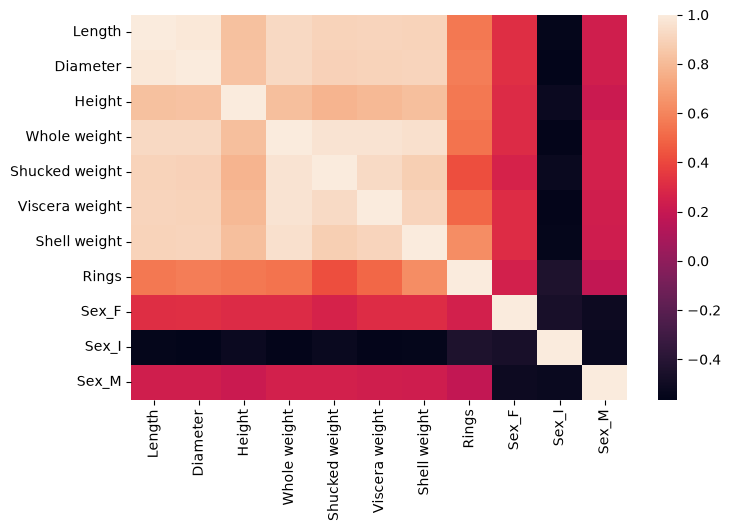

In [36]:
fig, ax = plt.subplots(figsize=(8, 5))#adjusting the size of the figure

#actually plotting the heatmap
sns.heatmap(df_3.corr())
plt.show()

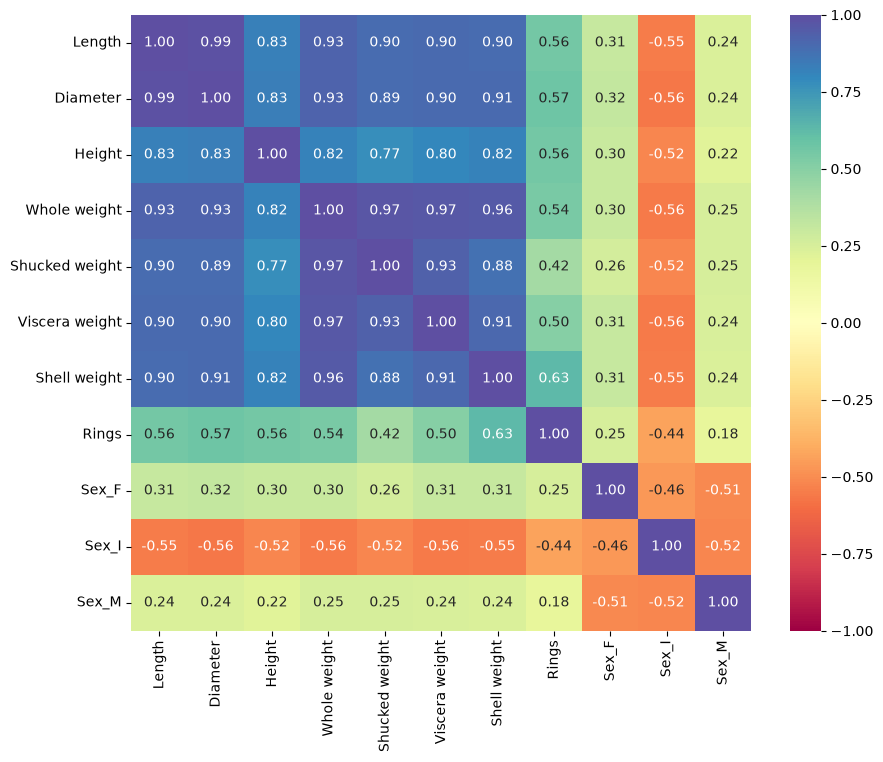

In [37]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(df_3.corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()

***Multi-Linear Regression***

In [38]:
columns = df_3.columns
columns

Index(['Length', 'Diameter', 'Height', 'Whole weight', 'Shucked weight',
       'Viscera weight', 'Shell weight', 'Rings', 'Sex_F', 'Sex_I', 'Sex_M'],
      dtype='str')

*Extracting the target and independent variables*

In [39]:
y_multilinear = df_3['Rings']
#x_multilinear = df_3.columns[1:]
#x_multilinear

In [40]:
y_multilinear

0       15
1        7
2        9
3       10
4        7
        ..
4172    11
4173    10
4174     9
4175    10
4176    12
Name: Rings, Length: 4177, dtype: int64

In [41]:
x_multilinear = df_3.drop(columns=['Rings'])
x_multilinear

,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Sex_F,Sex_I,Sex_M
0,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.1500,0.0,0.0,1.0
1,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.0700,0.0,0.0,1.0
2,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.2100,1.0,0.0,0.0
3,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.1550,0.0,0.0,1.0
4,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.0550,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...
4172,0.565,0.450,0.165,0.8870,0.3700,0.2390,0.2490,1.0,0.0,0.0
4173,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605,0.0,0.0,1.0
4174,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080,0.0,0.0,1.0
4175,0.625,0.485,0.150,1.0945,0.5310,0.2610,0.2960,1.0,0.0,0.0


*Spliting the Data*

In [42]:
x_train, x_test, y_train, y_test = train_test_split(x_multilinear, y_multilinear, test_size=30, random_state=42)

In [43]:
x_train

,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Sex_F,Sex_I,Sex_M
4110,0.510,0.410,0.155,1.2825,0.5690,0.2910,0.3795,0.0,0.0,1.0
2792,0.625,0.490,0.165,1.2050,0.5175,0.3105,0.3465,0.0,0.0,1.0
1829,0.365,0.270,0.085,0.1970,0.0815,0.0325,0.0650,0.0,1.0,0.0
690,0.500,0.375,0.150,0.6360,0.2535,0.1450,0.1900,0.0,0.0,1.0
1578,0.495,0.370,0.125,0.4715,0.2075,0.0910,0.1500,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...
3444,0.490,0.400,0.115,0.5690,0.2560,0.1325,0.1450,1.0,0.0,0.0
466,0.670,0.550,0.190,1.3905,0.5425,0.3035,0.4000,1.0,0.0,0.0
3092,0.510,0.395,0.125,0.5805,0.2440,0.1335,0.1880,0.0,0.0,1.0
3772,0.575,0.465,0.120,1.0535,0.5160,0.2185,0.2350,0.0,0.0,1.0


In [44]:
y_train

4110     9
2792    10
1829     6
690     10
1578     8
        ..
3444     9
466     12
3092    11
3772     9
860      6
Name: Rings, Length: 4147, dtype: int64

*get instance of the linear regression model*

In [45]:
multilinear_reg_model = LinearRegression()
multilinear_reg_model

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


*Fit the model*

In [46]:
multilinear_reg_model.fit(x_train, y_train)
multilinear_reg_model #trained model

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](10,)","[-0.27,10.86,10.66,..., 0.25,-0.57, 0.32]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](10,)","['Length','Diameter','Height',...,'Sex_F','Sex_I','Sex_M']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,3.638
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,10
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,9


*# 1. *Create dummy dataset with exactly 2 features*

In [47]:
np.random.seed(42)
X = np.random.rand(100, 2) * 10  # Features: X1, X2
y = 2 * X[:, 0] + 3 * X[:, 1] + np.random.randn(100) * 2  # Target

In [48]:
sns.lmplot(data=df_3.head(10), x='X1', y='y', ci=None, line_kws={'color':'red'})

KeyError: "None of [Index(['X1', 'y'], dtype='str')] are in the [columns]"